Juan Pablo Méndez Carrillo

A3.1 PCA y Sistemas de Recomendación



1. Introducción

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que permite transformar un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables no correlacionadas, llamadas componentes principales. Estas nuevas variables capturan la mayor cantidad de variabilidad posible en los datos, lo que facilita su análisis, visualización y procesamiento.

En este tutorial, PCA se utiliza en dos contextos principales. En primer lugar, se emplea como una etapa de preprocesamiento para mejorar el desempeño de modelos de clasificación y analizar la estructura interna de los datos. En segundo lugar, se explora su uso en la reconstrucción de datos incompletos mediante técnicas de matrix completion, permitiendo estimar valores faltantes a partir de patrones globales en el dataset.

De esta forma, se analiza tanto el impacto de la reducción de dimensionalidad en tareas supervisadas, como la capacidad de PCA para capturar la estructura subyacente de los datos en escenarios con información incompleta.

2. PCA para reducción de dimensionalidad y clasificación

2.1 Carga y exploración inicial del dataset

Se utilizará el dataset Breast Cancer Wisconsin, disponible en la librería scikit-learn. Este dataset contiene información sobre características de células tumorales, con el objetivo de clasificar tumores como benignos o malignos.

En esta sección se revisarán aspectos fundamentales como:

- Tamaño del dataset
- Tipo de variables
- Clases disponibles
- Presencia de valores faltantes

In [2]:
# Librerías
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Cargar dataset
data = load_breast_cancer()

# Convertir a DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Información básica
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# Primeras filas
display(X.head())

# Información general
X.info()

# Clases
print("\nClases:", data.target_names)
print("Distribución de clases:\n", y.value_counts())

# Valores faltantes
print("\nValores faltantes:\n", X.isnull().sum().sum())

Shape de X: (569, 30)
Shape de y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

El dataset contiene múltiples variables numéricas que describen características de células tumorales. No se observan valores faltantes, lo cual facilita el análisis.

Además, se cuenta con dos clases:
0: maligno
1: benigno

La distribución de clases permite evaluar si existe desbalance, lo cual puede influir en el desempeño del modelo de clasificación.

2.2 Exploración univariable y bivariable

Antes de entrenar cualquier modelo, es importante analizar cómo se comportan las variables del dataset y su capacidad para discriminar entre clases.

En esta sección se realizarán:

- Gráficas univariables (densidad): permiten observar la distribución de cada variable por clase
- Gráficas bivariable (dispersión): permiten visualizar la separabilidad entre clases usando pares de variables

Este análisis ayuda a entender si el problema es linealmente separable y qué variables podrían ser más relevantes para la clasificación.

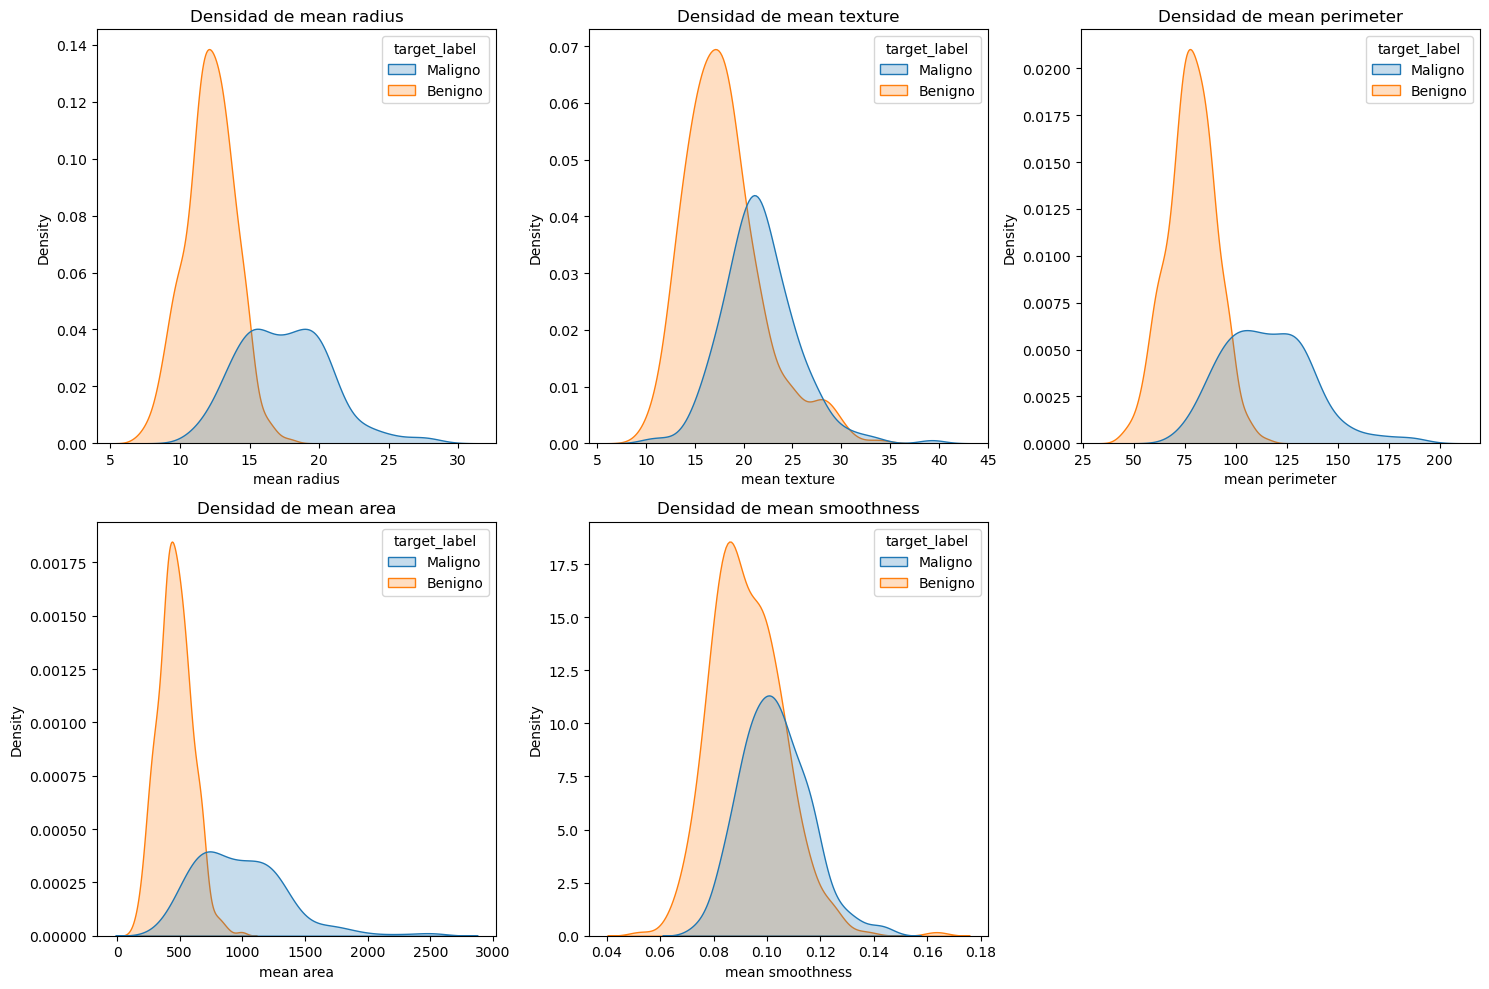

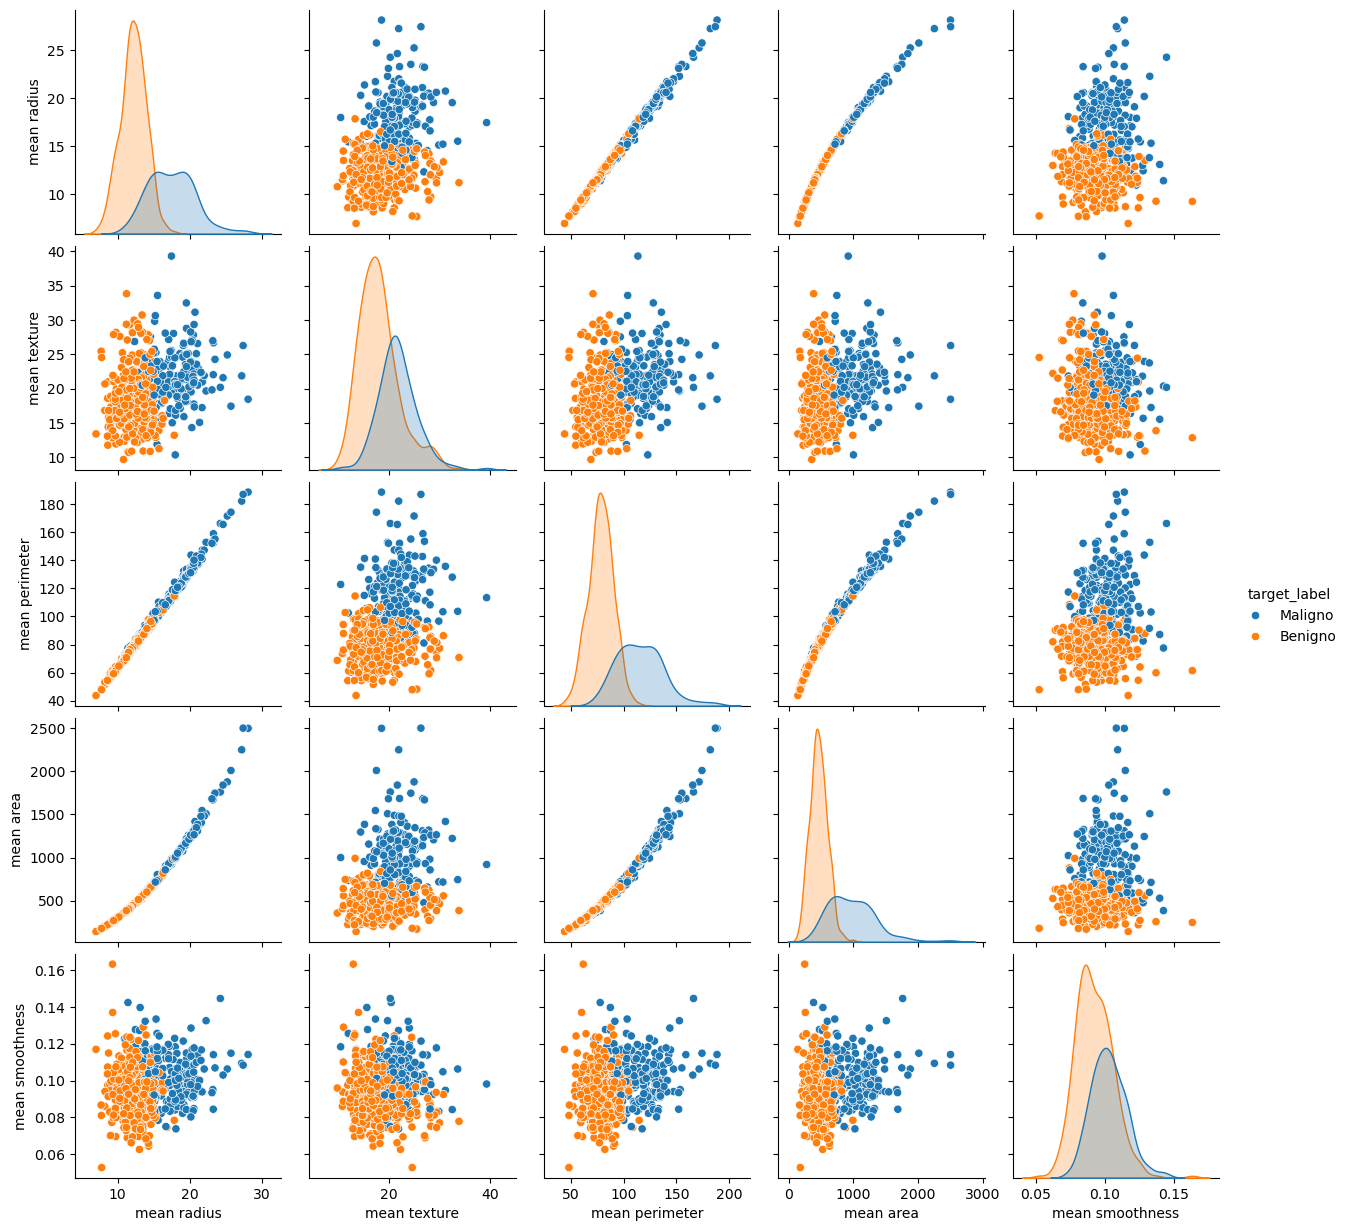

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combinar X y y en un solo DataFrame
df = X.copy()
df["target"] = y

# Mapear etiquetas para claridad
df["target_label"] = df["target"].map({0: "Maligno", 1: "Benigno"})

# -----------------------------
# Gráficas univariables (densidad)
# -----------------------------
features = X.columns[:5]  # puedes cambiar o ampliar

plt.figure(figsize=(15, 10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(data=df, x=col, hue="target_label", fill=True)
    plt.title(f"Densidad de {col}")

plt.tight_layout()
plt.show()

# -----------------------------
# Gráficas bivariable (dispersión)
# -----------------------------
sns.pairplot(df[features.tolist() + ["target_label"]],
             hue="target_label",
             diag_kind="kde")

plt.show()

Las gráficas de densidad permiten observar cómo se distribuyen las variables para cada clase. En algunos casos, se aprecia una separación clara entre tumores benignos y malignos, lo que indica que ciertas variables tienen buen poder discriminativo.

Por otro lado, las gráficas de dispersión muestran la relación entre pares de variables. Si las clases forman grupos bien definidos, esto sugiere que el modelo de clasificación podría tener un buen desempeño.

Sin embargo, también se pueden observar variables correlacionadas, lo cual es relevante ya que PCA busca precisamente eliminar redundancia y capturar la información más importante en menos dimensiones.

2.3 Preprocesamiento

Antes de entrenar el modelo de clasificación, es necesario preparar los datos adecuadamente.

En esta sección se realizarán dos pasos fundamentales:

- División en conjunto de entrenamiento y prueba: Se separarán los datos en 70% para entrenamiento y 30% para prueba, con el objetivo de evaluar el desempeño del modelo en datos no vistos.
  
- Estandarización de las variables: Dado que PCA y la regresión logística son sensibles a la escala de las variables, se transformarán los datos para que tengan media 0 y desviación estándar 1. Esto asegura que todas las variables tengan la misma importancia en el modelo.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# Estandarización
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mantener interpretabilidad
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verificación básica
print("\nMedia (train):\n", X_train_scaled.mean().round(2))
print("\nDesviación estándar (train):\n", X_train_scaled.std().round(2))

Train shape: (398, 30)
Test shape: (171, 30)

Media (train):
 mean radius               -0.0
mean texture               0.0
mean perimeter             0.0
mean area                  0.0
mean smoothness            0.0
mean compactness          -0.0
mean concavity            -0.0
mean concave points       -0.0
mean symmetry             -0.0
mean fractal dimension     0.0
radius error               0.0
texture error              0.0
perimeter error           -0.0
area error                 0.0
smoothness error           0.0
compactness error          0.0
concavity error            0.0
concave points error      -0.0
symmetry error            -0.0
fractal dimension error   -0.0
worst radius              -0.0
worst texture             -0.0
worst perimeter           -0.0
worst area                -0.0
worst smoothness           0.0
worst compactness         -0.0
worst concavity           -0.0
worst concave points      -0.0
worst symmetry            -0.0
worst fractal dimension    0.0
dtype: f

La división de los datos se realizó correctamente, obteniendo 398 observaciones para entrenamiento y 171 para prueba, lo cual corresponde a una partición del 70% y 30% respectivamente.

En cuanto a la estandarización, se observa que todas las variables en el conjunto de entrenamiento tienen una media cercana a 0 y una desviación estándar de 1. Esto confirma que el proceso de escalado se aplicó correctamente.

Este paso es fundamental, ya que asegura que todas las variables contribuyan de manera equitativa al modelo, evitando que aquellas con mayor magnitud dominen el proceso de aprendizaje. Además, la estandarización es un requisito importante para PCA, ya que esta técnica depende directamente de la varianza de las variables.

2.4 Modelo base (Regresión Logística)

Antes de aplicar PCA, se entrena un modelo base de regresión logística utilizando los datos originales (ya estandarizados).

Este modelo servirá como referencia para evaluar posteriormente si la aplicación de PCA mejora o afecta el desempeño.

Se utilizarán las siguientes métricas de evaluación:

- Accuracy: proporción de predicciones correctas
- F1 score: balance entre precisión y recall
- AUC: capacidad del modelo para distinguir entre clases

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Modelo
model = LogisticRegression(max_iter=10000)

# Entrenamiento
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Métricas
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("AUC:", auc)

Accuracy: 0.9883040935672515
F1 Score: 0.9906542056074766
AUC: 0.9981016355140186


El modelo de regresión logística presenta un desempeño muy alto en el conjunto de prueba. Se obtiene una exactitud (accuracy) cercana al 99%, lo que indica que la gran mayoría de las predicciones son correctas.

El F1 score también es elevado, lo que sugiere un buen equilibrio entre precisión y recall, es decir, el modelo no solo clasifica correctamente, sino que también logra identificar adecuadamente ambas clases.

Por su parte, el valor de AUC es cercano a 1, lo que indica una excelente capacidad del modelo para distinguir entre tumores benignos y malignos.

Estos resultados muestran que el dataset es altamente separable con un modelo lineal, por lo que servirá como una buena referencia para evaluar el impacto de aplicar PCA posteriormente.

2.5 PCA y análisis de correlación

El Análisis de Componentes Principales (PCA) se utiliza para transformar el conjunto original de variables en un nuevo espacio de menor dimensión, donde las variables resultantes (componentes principales) son no correlacionadas y capturan la mayor parte de la variabilidad de los datos.

Antes de aplicar PCA, es importante analizar la correlación entre variables, ya que esta técnica es especialmente útil cuando existen relaciones lineales fuertes entre ellas.

En esta sección se realizará:

- Análisis de correlación mediante heatmaps
- Aplicación de PCA sobre los datos estandarizados
- Transformación del dataset a un nuevo espacio de características

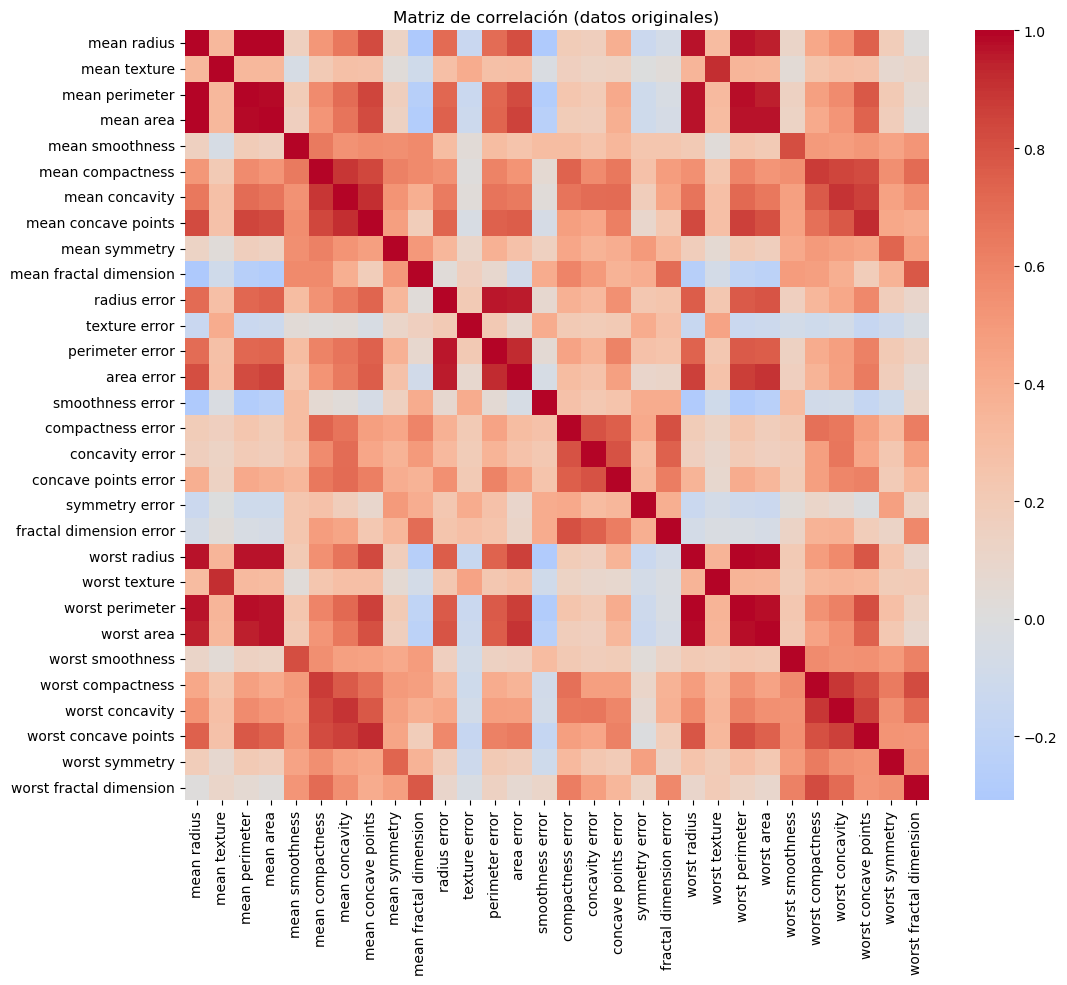

Shape original: (398, 30)
Shape con PCA: (398, 30)


In [5]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Heatmap de correlación (antes de PCA)
# -----------------------------
plt.figure(figsize=(12,10))
sns.heatmap(X_train_scaled.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación (datos originales)")
plt.show()

# -----------------------------
# PCA (sin limitar componentes aún)
# -----------------------------
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Convertir a DataFrame
X_train_pca = pd.DataFrame(X_train_pca)
X_test_pca = pd.DataFrame(X_test_pca)

print("Shape original:", X_train_scaled.shape)
print("Shape con PCA:", X_train_pca.shape)

La matriz de correlación muestra que existen múltiples variables altamente correlacionadas entre sí, especialmente dentro de grupos como:

- Variables relacionadas con tamaño (radius, perimeter, area)
- Variables de “worst” (mediciones extremas)
- Variables asociadas a concavidad y compactación

Estas correlaciones indican redundancia en la información, ya que varias variables están aportando contenido similar. Esto es precisamente el tipo de estructura que PCA busca aprovechar, al combinar variables correlacionadas en componentes principales no correlacionados.

Además, se observan algunas correlaciones negativas, aunque en menor proporción, lo que también contribuye a la variabilidad total del sistema.

En cuanto a las dimensiones, PCA no reduce automáticamente el número de variables en esta etapa, sino que transforma el espacio original en uno nuevo con el mismo número de componentes. La reducción de dimensionalidad se logrará posteriormente al seleccionar solo los componentes más relevantes.

2.6 Varianza explicada

Una de las principales ventajas de PCA es que permite identificar cuánta información (varianza) aporta cada componente principal.

En esta sección se analizará:

- La varianza explicada individual (scree plot) para identificar el “codo”
- La varianza explicada acumulada para determinar cuántos componentes son necesarios para capturar un porcentaje significativo de la información (por ejemplo, 60%, 70%, 80%, etc.)

Esto permitirá seleccionar una cantidad óptima de componentes para reducir la dimensionalidad sin perder demasiada información.

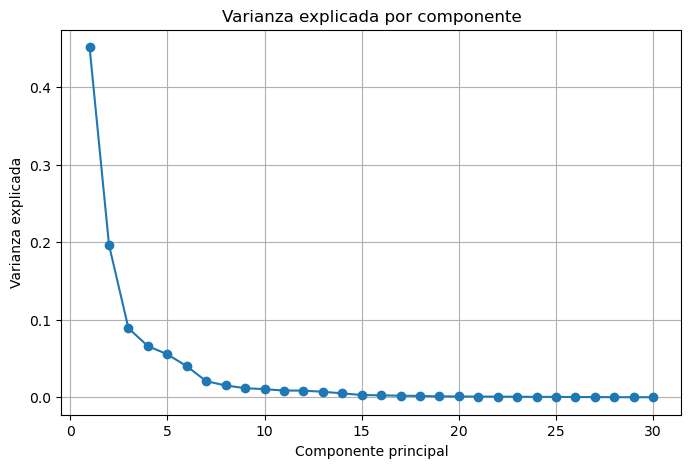

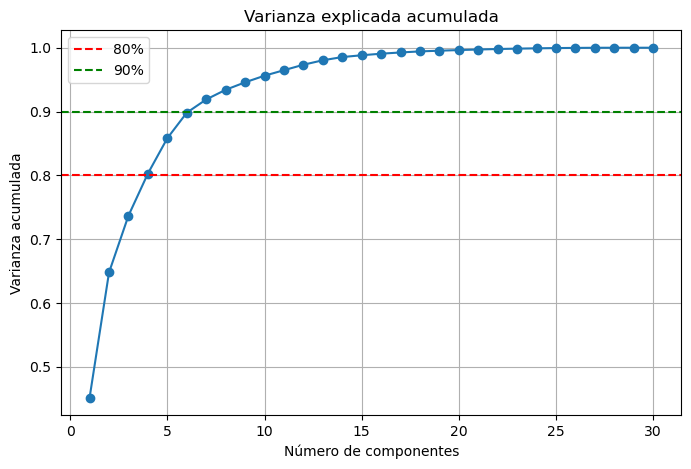

Componentes para 60%: 2
Componentes para 70%: 3
Componentes para 80%: 4
Componentes para 90%: 7


In [6]:
# Varianza explicada
explained_variance = pca.explained_variance_ratio_

# -----------------------------
# Scree plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Varianza explicada por componente")
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.grid()
plt.show()

# -----------------------------
# Varianza acumulada
# -----------------------------
cumulative_variance = explained_variance.cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.axhline(y=0.9, color='g', linestyle='--', label='90%')
plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Componentes necesarios
# -----------------------------
for threshold in [0.6, 0.7, 0.8, 0.9]:
    num_components = (cumulative_variance >= threshold).argmax() + 1
    print(f"Componentes para {int(threshold*100)}%: {num_components}")

El análisis de varianza explicada muestra que una pequeña cantidad de componentes principales es capaz de capturar una proporción significativa de la variabilidad del dataset.

En particular, se observa que:

- 2 componentes explican aproximadamente el 60% de la varianza
- 3 componentes alcanzan el 70%
- 4 componentes llegan al 80%
- 7 componentes permiten alcanzar el 90%

El gráfico de varianza explicada presenta un “codo” alrededor de los primeros componentes, lo que indica que la mayor parte de la información relevante se concentra en un número reducido de dimensiones. A partir de este punto, la incorporación de nuevos componentes aporta mejoras marginales.

Esto sugiere que es posible reducir significativamente la dimensionalidad del problema sin perder demasiada información, lo cual puede simplificar el modelo y reducir redundancia entre variables.

2.7 Modelos con PCA y comparación

Una vez identificada la cantidad de componentes principales necesarios para capturar la mayor parte de la varianza, se procede a entrenar modelos de clasificación utilizando estos nuevos conjuntos de datos reducidos.

El objetivo es evaluar cómo afecta la reducción de dimensionalidad al desempeño del modelo, comparando los resultados con el modelo base.

Se entrenarán modelos utilizando diferentes cantidades de componentes principales (por ejemplo: 2, 3, 4 y 7), correspondientes a distintos niveles de varianza explicada.

In [7]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

component_list = [2, 3, 4, 7]

results = []

for n in component_list:
    # PCA con n componentes
    pca_n = PCA(n_components=n)
    
    X_train_pca_n = pca_n.fit_transform(X_train_scaled)
    X_test_pca_n = pca_n.transform(X_test_scaled)
    
    # Modelo
    model = LogisticRegression(max_iter=10000)
    model.fit(X_train_pca_n, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test_pca_n)
    y_prob = model.predict_proba(X_test_pca_n)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append((n, acc, f1, auc))

# Mostrar resultados
for r in results:
    print(f"Componentes: {r[0]} | Accuracy: {r[1]:.4f} | F1: {r[2]:.4f} | AUC: {r[3]:.4f}")

Componentes: 2 | Accuracy: 0.9474 | F1: 0.9581 | AUC: 0.9924
Componentes: 3 | Accuracy: 0.9298 | F1: 0.9444 | AUC: 0.9882
Componentes: 4 | Accuracy: 0.9532 | F1: 0.9636 | AUC: 0.9958
Componentes: 7 | Accuracy: 0.9591 | F1: 0.9668 | AUC: 0.9956


Al comparar los modelos entrenados con diferentes cantidades de componentes principales, se observa que la reducción de dimensionalidad mediante PCA mantiene un desempeño alto, aunque ligeramente inferior al modelo base en algunos casos.

En particular:
- Con 2 componentes, el modelo ya alcanza un desempeño elevado, lo que indica que una gran parte de la información relevante está concentrada en muy pocas dimensiones.
- Con 3 componentes, se observa una ligera disminución en las métricas, lo cual puede deberse a una pérdida de información relevante en la transformación.
- A partir de 4 y 7 componentes, el desempeño mejora nuevamente, acercándose más al modelo original, lo que sugiere que estos niveles de varianza explicada conservan mejor la estructura del dataset.

En comparación con el modelo base, que presentaba métricas cercanas al óptimo, se puede concluir que PCA permite reducir significativamente la dimensionalidad (de 30 variables a aproximadamente 4–7 componentes) manteniendo un desempeño competitivo.

Esto demuestra que existe redundancia en las variables originales, y que es posible simplificar el modelo sin una pérdida considerable de capacidad predictiva.

2.8 Interpretación

Además de reducir dimensionalidad, PCA permite interpretar qué variables originales contribuyen más a cada componente principal.

Esto se logra a través de las cargas (loadings), que indican el peso de cada variable en cada componente.

Analizar las cargas permite:

- Identificar qué variables tienen mayor influencia
- Entender qué representa cada componente principal
- Dar interpretabilidad al modelo transformado

In [8]:
# Usamos el PCA completo ya entrenado previamente
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(X.columns))],
    index=X.columns
)

# Mostrar las variables más importantes para los primeros componentes
for i in range(3):  # primeros 3 componentes
    print(f"\nTop variables para PC{i+1}:")
    print(loadings[f"PC{i+1}"].sort_values(key=abs, ascending=False).head(5))


Top variables para PC1:
mean concave points     0.259088
mean concavity          0.253645
worst concave points    0.250057
mean compactness        0.239204
worst perimeter         0.235089
Name: PC1, dtype: float64

Top variables para PC2:
mean fractal dimension     0.361301
fractal dimension error    0.279409
worst fractal dimension    0.268941
compactness error          0.235564
mean radius               -0.232248
Name: PC2, dtype: float64

Top variables para PC3:
texture error       0.429956
worst smoothness   -0.292696
smoothness error    0.258094
symmetry error      0.249784
worst symmetry     -0.249243
Name: PC3, dtype: float64


El análisis de las cargas (loadings) permite identificar qué variables originales tienen mayor influencia en cada componente principal.

Para el primer componente principal (PC1), las variables con mayor peso están relacionadas con la concavidad, compactación y puntos cóncavos, así como medidas extremas como worst perimeter. Esto sugiere que este componente captura principalmente características asociadas a la forma y estructura del tumor, las cuales son relevantes para distinguir entre tumores benignos y malignos.

En el segundo componente (PC2), destacan variables relacionadas con la dimensión fractal y errores asociados, lo que indica que este componente está capturando patrones más sutiles relacionados con la complejidad geométrica de las células.

Por otro lado, el tercer componente (PC3) está influenciado por variables como texture error, smoothness y symmetry, lo que sugiere que este componente representa características relacionadas con la variabilidad y regularidad de la textura celular.

2.9 Visualización con PCA

Una de las ventajas principales de PCA es que permite representar datos de alta dimensionalidad en un espacio de menor dimensión, facilitando su visualización.

En esta sección se proyectarán los datos sobre los primeros dos componentes principales y se generarán gráficas de dispersión para analizar la separabilidad entre clases.

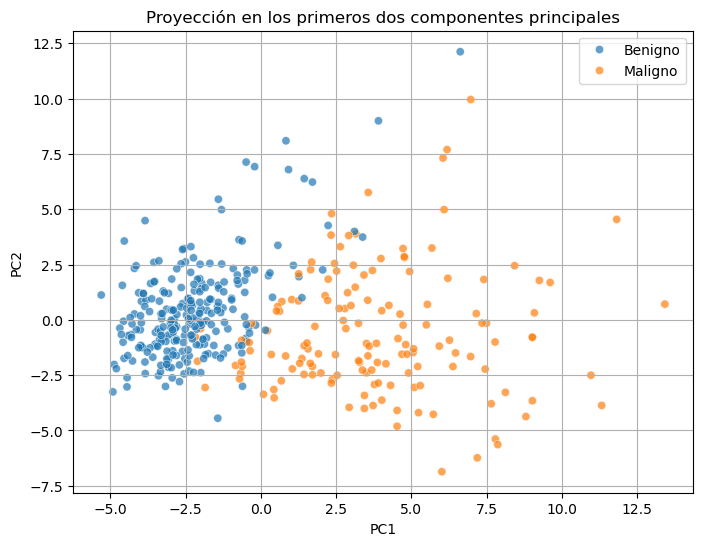

In [9]:
# Usamos los primeros dos componentes
X_train_pca_2 = X_train_pca.iloc[:, :2].copy()
X_train_pca_2["target"] = y_train.values

# Mapear etiquetas
X_train_pca_2["target_label"] = X_train_pca_2["target"].map({0: "Maligno", 1: "Benigno"})

# Gráfica
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_train_pca_2,
    x=0,
    y=1,
    hue="target_label",
    alpha=0.7
)

plt.title("Proyección en los primeros dos componentes principales")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

La proyección de los datos en los primeros dos componentes principales muestra que existe una separación general entre las clases, aunque con cierto grado de traslape.

Se observa que los tumores benignos y malignos tienden a agruparse en regiones distintas del plano definido por PC1 y PC2, lo que indica que estos componentes capturan información relevante para la clasificación. Sin embargo, la presencia de traslape sugiere que dos componentes no son suficientes para separar completamente las clases.

Esto es consistente con el análisis previo de varianza explicada, donde se observó que los primeros dos componentes capturan alrededor del 60% de la variabilidad total. Por lo tanto, aunque permiten una buena visualización, se requiere un mayor número de componentes para preservar mejor la estructura del dataset y alcanzar un desempeño óptimo en clasificación.

3. PCA para imputación de datos mediante matrix completion

3.1 Dataset

En esta sección se utilizará el dataset Wine, disponible en la librería scikit-learn. Este dataset contiene características químicas de diferentes vinos, con el objetivo de clasificarlos en distintas categorías.

Se realizará una revisión inicial del dataset para comprender su estructura, incluyendo el número de observaciones, variables y clases.

In [3]:
from sklearn.datasets import load_wine

# Cargar dataset
data = load_wine()

# Convertir a DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Información básica
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

display(X.head())

# Clases
print("\nClases:", data.target_names)
print("Distribución de clases:\n", y.value_counts())

# Valores faltantes
print("\nValores faltantes:", X.isnull().sum().sum())

Shape de X: (178, 13)
Shape de y: (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Clases: ['class_0' 'class_1' 'class_2']
Distribución de clases:
 target
1    71
0    59
2    48
Name: count, dtype: int64

Valores faltantes: 0


El dataset Wine contiene 178 observaciones con 13 variables numéricas que describen características químicas de los vinos. La variable objetivo está compuesta por tres clases distintas, con una distribución relativamente balanceada entre ellas, aunque con una ligera predominancia de la clase 1.

No se presentan valores faltantes en el dataset original, lo cual permite trabajar inicialmente con datos completos antes de introducir artificialmente valores ausentes en etapas posteriores del análisis.

3.2 Preprocesamiento

Al igual que en la sección anterior, se realizará una preparación de los datos para su uso en modelos de clasificación.

Los pasos incluyen:
- División en conjunto de entrenamiento y prueba (70% / 30%)
- Estandarización de las variables para asegurar que todas tengan la misma escala

Este paso es especialmente importante para modelos como regresión logística y técnicas como PCA.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# Estandarización
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verificación
print("\nMedia (train):\n", X_train_scaled.mean().round(2))
print("\nStd (train):\n", X_train_scaled.std().round(2))

Train shape: (124, 13)
Test shape: (54, 13)

Media (train):
 alcohol                         0.0
malic_acid                      0.0
ash                             0.0
alcalinity_of_ash               0.0
magnesium                      -0.0
total_phenols                   0.0
flavanoids                      0.0
nonflavanoid_phenols           -0.0
proanthocyanins                 0.0
color_intensity                -0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

Std (train):
 alcohol                         1.0
malic_acid                      1.0
ash                             1.0
alcalinity_of_ash               1.0
magnesium                       1.0
total_phenols                   1.0
flavanoids                      1.0
nonflavanoid_phenols            1.0
proanthocyanins                 1.0
color_intensity                 1.0
hue                             1.0
od280/od315_of_diluted_wines    1.0
proline  

La división del dataset se realizó correctamente, obteniendo 124 observaciones para entrenamiento y 54 para prueba, lo cual corresponde a una partición del 70% y 30%.

La estandarización también se aplicó de forma adecuada, ya que todas las variables del conjunto de entrenamiento presentan una media cercana a 0 y una desviación estándar de 1. Esto garantiza que ninguna variable domine el modelo debido a su escala y asegura un comportamiento adecuado tanto para la regresión logística como para técnicas posteriores como PCA.

3.3 Modelo base (clasificación)

Se entrena un modelo de regresión logística utilizando los datos estandarizados sin valores faltantes. Este modelo servirá como referencia para evaluar el impacto de introducir datos faltantes y aplicar diferentes técnicas de imputación.

Se evaluará el desempeño utilizando las métricas:
- Accuracy
- F1 score (macro, ya que hay múltiples clases)
- AUC

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Modelo
model = LogisticRegression(max_iter=10000)

# Entrenamiento
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

# AUC multiclase
y_test_bin = label_binarize(y_test, classes=[0,1,2])
auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")

print("Accuracy:", accuracy)
print("F1 Score (macro):", f1)
print("AUC:", auc)

Accuracy: 0.9814814814814815
F1 Score (macro): 0.9828609096901779
AUC: 0.9995189995189996


El modelo base de regresión logística presenta un desempeño muy alto en el conjunto de prueba, con una exactitud superior al 98% y un F1 score macro cercano a 0.98, lo que indica un buen equilibrio en la clasificación de las tres clases.

El valor de AUC es prácticamente igual a 1, lo que refleja una excelente capacidad del modelo para distinguir entre las diferentes categorías de vino.

Estos resultados servirán como referencia para evaluar el impacto negativo de introducir datos faltantes y la efectividad de las distintas estrategias de imputación que se aplicarán posteriormente.

3.4 Introducción de datos faltantes

Para simular un escenario más realista, se eliminará de forma aleatoria el 30% de los valores en el dataset, tanto en el conjunto de entrenamiento como en el de prueba.

Es importante notar que solo se eliminan valores de las variables de entrada (X), y la variable objetivo (y) permanece intacta. Posteriormente, se visualizarán los valores faltantes mediante un heatmap para observar su distribución.

Missing en train: 483
Missing en test: 212


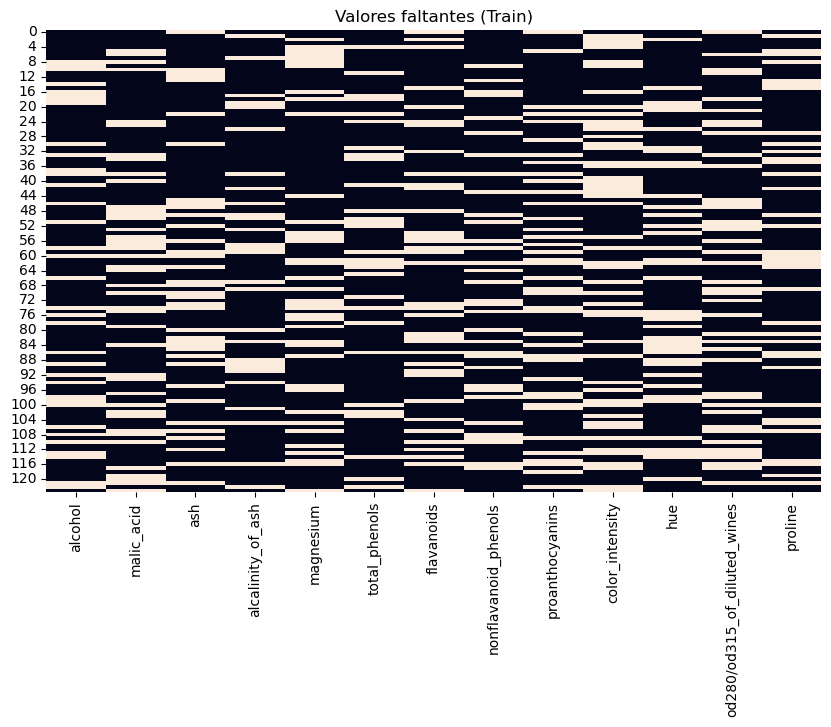

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copias para no perder los originales
X_train_missing = X_train_scaled.copy()
X_test_missing = X_test_scaled.copy()

# Función para introducir missing values
def introduce_missing(X, missing_rate=0.3):
    X_missing = X.copy()
    mask = np.random.rand(*X_missing.shape) < missing_rate
    X_missing[mask] = np.nan
    return X_missing

# Aplicar
X_train_missing = introduce_missing(X_train_missing, 0.3)
X_test_missing = introduce_missing(X_test_missing, 0.3)

# Verificación
print("Missing en train:", X_train_missing.isnull().sum().sum())
print("Missing en test:", X_test_missing.isnull().sum().sum())

# -----------------------------
# Heatmap de valores faltantes
# -----------------------------
plt.figure(figsize=(10,6))
sns.heatmap(X_train_missing.isnull(), cbar=False)
plt.title("Valores faltantes (Train)")
plt.show()

Se introdujeron valores faltantes de manera aleatoria en aproximadamente el 30% de los datos, lo cual se refleja en la cantidad total de valores ausentes tanto en el conjunto de entrenamiento como en el de prueba.

El heatmap muestra que los valores faltantes se distribuyen de forma dispersa a lo largo de las distintas variables y observaciones, sin concentrarse en columnas o filas específicas. Esto indica que el patrón de missing data es aleatorio, lo cual es un supuesto importante para muchas técnicas de imputación.

Este escenario simula una situación realista en la que los datos incompletos pueden afectar el desempeño de los modelos, justificando la necesidad de aplicar estrategias de imputación para reconstruir la información faltante.

3.5 Imputación (Media y KNN)

Para manejar los valores faltantes, se aplicarán dos estrategias de imputación:

- Imputación por media: reemplaza los valores faltantes con el promedio de cada variable
- Imputación por KNN: utiliza la información de observaciones similares para estimar los valores faltantes

Posteriormente, se entrenarán modelos de regresión logística con cada uno de los datasets imputados y se evaluará su desempeño.

In [9]:
from sklearn.impute import SimpleImputer, KNNImputer

# -----------------------------
# Imputación por media
# -----------------------------
mean_imputer = SimpleImputer(strategy="mean")

X_train_mean = mean_imputer.fit_transform(X_train_missing)
X_test_mean = mean_imputer.transform(X_test_missing)

# -----------------------------
# Imputación por KNN
# -----------------------------
knn_imputer = KNNImputer(n_neighbors=5)

X_train_knn = knn_imputer.fit_transform(X_train_missing)
X_test_knn = knn_imputer.transform(X_test_missing)

# Convertir a DataFrame
X_train_mean = pd.DataFrame(X_train_mean, columns=X.columns)
X_test_mean = pd.DataFrame(X_test_mean, columns=X.columns)

X_train_knn = pd.DataFrame(X_train_knn, columns=X.columns)
X_test_knn = pd.DataFrame(X_test_knn, columns=X.columns)

In [10]:
results = {}

for name, Xtr, Xte in [
    ("Mean", X_train_mean, X_test_mean),
    ("KNN", X_train_knn, X_test_knn)
]:
    model = LogisticRegression(max_iter=10000)
    model.fit(Xtr, y_train)
    
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2]), y_prob, multi_class="ovr")
    
    results[name] = (acc, f1, auc)

# Mostrar resultados
for k, v in results.items():
    print(f"{k} → Accuracy: {v[0]:.4f} | F1: {v[1]:.4f} | AUC: {v[2]:.4f}")

Mean → Accuracy: 0.9630 | F1: 0.9639 | AUC: 0.9920
KNN → Accuracy: 0.9259 | F1: 0.9275 | AUC: 0.9930


Los resultados muestran que ambas estrategias de imputación permiten recuperar un buen nivel de desempeño en el modelo de clasificación, aunque con una ligera disminución respecto al modelo base sin valores faltantes.

La imputación por media presenta un mejor desempeño en términos de accuracy y F1 score, lo que indica que, en este caso, una estrategia simple es suficiente para preservar la estructura general de los datos.

Por otro lado, la imputación por KNN muestra un desempeño ligeramente inferior en accuracy y F1, aunque mantiene un valor de AUC alto. Esto sugiere que, si bien KNN puede capturar relaciones locales entre observaciones, también puede introducir ruido o variabilidad adicional dependiendo de la distribución de los datos.

3.6 Matrix Completion con PCA (SoftImpute)

Una alternativa más avanzada para manejar datos faltantes es utilizar técnicas de matrix completion, las cuales buscan reconstruir la matriz original aprovechando su estructura interna.

En este caso, se utilizará el algoritmo SoftImpute, el cual se basa en una aproximación iterativa inspirada en PCA para estimar los valores faltantes.

A diferencia de métodos simples como la media o KNN, esta técnica onsidera relaciones globales entre variables, busca una representación de baja dimensión y reconstruye los datos de forma iterativa. Este tipo de enfoques es la base de muchos sistemas de recomendación, donde se busca completar matrices incompletas de interacciones entre usuarios y elementos.

Posteriormente, se evaluará el desempeño del modelo utilizando los datos imputados mediante esta técnica y se comparará con los métodos anteriores.

In [18]:
from fancyimpute import SoftImpute

# Aplicar SoftImpute por separado a train y test
X_train_soft = SoftImpute().fit_transform(X_train_missing)
X_test_soft = SoftImpute().fit_transform(X_test_missing)

# Convertir a DataFrame
X_train_soft = pd.DataFrame(X_train_soft, columns=X.columns)
X_test_soft = pd.DataFrame(X_test_soft, columns=X.columns)
import warnings

[SoftImpute] Max Singular Value of X_init = 18.957537
[SoftImpute] Iter 1: observed MAE=0.031363 rank=13
[SoftImpute] Iter 2: observed MAE=0.031408 rank=13
[SoftImpute] Iter 3: observed MAE=0.031451 rank=13
[SoftImpute] Iter 4: observed MAE=0.031494 rank=13
[SoftImpute] Iter 5: observed MAE=0.031534 rank=13
[SoftImpute] Iter 6: observed MAE=0.031573 rank=13
[SoftImpute] Iter 7: observed MAE=0.031613 rank=13
[SoftImpute] Iter 8: observed MAE=0.031650 rank=13
[SoftImpute] Iter 9: observed MAE=0.031685 rank=13
[SoftImpute] Iter 10: observed MAE=0.031718 rank=13
[SoftImpute] Iter 11: observed MAE=0.031749 rank=13
[SoftImpute] Iter 12: observed MAE=0.031778 rank=13
[SoftImpute] Iter 13: observed MAE=0.031804 rank=13
[SoftImpute] Iter 14: observed MAE=0.031829 rank=13
[SoftImpute] Iter 15: observed MAE=0.031853 rank=13
[SoftImpute] Iter 16: observed MAE=0.031876 rank=13
[SoftImpute] Iter 17: observed MAE=0.031899 rank=13
[SoftImpute] Iter 18: observed MAE=0.031919 rank=13
[SoftImpute] Iter 1

In [19]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_soft, y_train)

y_pred = model.predict(X_test_soft)
y_prob = model.predict_proba(X_test_soft)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2]), y_prob, multi_class="ovr")

print("SoftImpute → Accuracy:", acc)
print("SoftImpute → F1:", f1)
print("SoftImpute → AUC:", auc)

SoftImpute → Accuracy: 0.9074074074074074
SoftImpute → F1: 0.9104466592838687
SoftImpute → AUC: 0.9931323820212709


In [20]:
# Comparar solo donde había valores faltantes
mask_train = X_train_missing.isnull()

# Convertir originales a numpy
X_train_original = X_train_scaled.values
X_train_soft_np = X_train_soft.values

# Error (MSE en valores que eran missing)
mse = ((X_train_original[mask_train] - X_train_soft_np[mask_train])**2).mean()

print("Error de reconstrucción (MSE):", mse)

Error de reconstrucción (MSE): 0.5838280465685094


El uso de SoftImpute como técnica de matrix completion permite reconstruir los valores faltantes aprovechando la estructura global de los datos mediante una aproximación basada en PCA.

En términos de desempeño del modelo:
- Se observa una disminución en accuracy y F1 score en comparación con la imputación por media, lo que indica que la reconstrucción no preserva completamente la separabilidad original de las clases.
- Sin embargo, el valor de AUC se mantiene alto, lo que sugiere que el modelo conserva una buena capacidad para distinguir entre clases, aunque con menor precisión en la clasificación final.

En cuanto a la calidad de reconstrucción, el error MSE obtenido refleja que existe una diferencia apreciable entre los valores originales y los imputados. Esto indica que, aunque SoftImpute captura patrones globales en los datos, no siempre logra reconstrucciones precisas a nivel individual, especialmente en datasets pequeños o con estructuras complejas.

Al comparar los métodos:
- Imputación por media resultó ser la más efectiva en este caso
- KNN mostró un desempeño intermedio
- SoftImpute no superó a los métodos anteriores, a pesar de ser más sofisticado

Esto sugiere que la complejidad del método no garantiza un mejor desempeño, y que la efectividad de cada técnica depende de la naturaleza del dataset y del patrón de datos faltantes.

4. Conclusión

En este tutorial se exploró el uso de PCA tanto para reducción de dimensionalidad como para reconstrucción de datos en presencia de valores faltantes.

En la primera parte, se demostró que PCA permite reducir significativamente la dimensionalidad del dataset sin perder desempeño considerable en tareas de clasificación, evidenciando la existencia de redundancia entre variables.

En la segunda parte, se analizó el impacto de los datos faltantes y se compararon distintas estrategias de imputación. Se observó que, aunque métodos avanzados como SoftImpute aprovechan la estructura global de los datos, no siempre superan a técnicas más simples como la imputación por media.